# P2 실습: 딥러닝 프로젝트 유형

**감사의 글**

아래 내용은 프랑소와 숄레의 
[Deep Learning with Python(3판)](https://github.com/fchollet/deep-learning-with-python-notebooks)의 
소스코드 내용을 참고해서 작성되었습니다.
자료를 공개한 저자에게 진심어린 감사를 전합니다.

**코드 실행**

[(구글 코랩) P2 실습: 딥러닝 프로젝트 유형](https://colab.research.google.com/github/codingalzi/code-workout-dlp/blob/master/P2_lab_dl_project_types.ipynb)에서 코드를 실행할 수 있다.

**주요 내용**

딥러닝 프로젝트는 해결하려는 문제의 성격에 따라 여러 유형으로 나눌 수 있다.
이번 실습에서는 대표적인 유형인 **이진 분류, 다중 클래스 분류, 회귀**를 살펴본다.

다루는 문제의 유형에 따라 **출력층, 손실함수, 평가지표가 어떻게 달라지는지** 비교하고,
훈련 성능과 검증 성능을 함께 관찰하여 **일반화와 과대적합**을 확인한다.
또한 교차 검증과 규제 기법을 이용하여 모델의 일반화 성능을 평가하고 개선한다.

이번 실습의 흐름은 다음과 같다.

> **이진 분류 → 다중 클래스 분류 → 회귀 → 일반화 성능 평가 및 개선**

사용하는 데이터셋은 다음과 같다.

- IMDB 영화 후기: 이진 분류
- Reuters 뉴스 기사: 다중 클래스 분류
- California Housing: 회귀

**설정: TensorFlow와 Keras의 GPU 사용 가능 여부 확인**

In [ ]:
# TensorFlow 를 사용할 때 기타 정보 표시 제한. Tensorflow를 불러오기 전에 실행해야 함
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import torch

# TensorFlow
tf_gpus = tf.config.list_physical_devices("GPU")

print("=== TensorFlow ===")
print("Version:", tf.__version__)
print("GPU 사용 가능:", len(tf_gpus) > 0)
if tf_gpus:
    print("GPU:", tf_gpus[0].name)

print()

# PyTorch
print("=== PyTorch ===")
print("Version:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

=== TensorFlow ===
Version: 2.20.0
GPU 사용 가능: True
GPU: /physical_device:GPU:0

=== PyTorch ===
Version: 2.9.1+cu128
GPU 사용 가능: True
GPU: NVIDIA RTX A6000
CUDA version: 12.8


**필수 라이브러리**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

## 문제 유형에 따라 무엇이 달라질까?

세 문제는 모두 완전연결 신경망으로 해결할 수 있지만 **타깃의 의미가 다르다.**

| 문제 | 타깃 | 출력층 | 대표 손실함수 | 대표 평가지표 |
|---|---|---|---|---|
| 이진 분류 | 두 클래스 중 하나 | 유닛 1개 + sigmoid | binary crossentropy | accuracy |
| 다중 클래스 분류 | 여러 클래스 중 하나 | 범주 개수만큼의 유닛 + softmax | sparse categorical crossentropy | accuracy |
| 회귀 | 연속적인 수치 | 유닛 1개, 활성화 함수 없음 | MSE | RMSE |

## 이진 분류: IMDB 영화 후기

영화 후기의 내용을 이용하여 후기가 **긍정인지 부정인지** 예측한다.

- 입력: 영화 후기
- 타깃: `0`(부정), `1`(긍정)
- 문제 유형: **이진 분류**

**IMDB 데이터 불러오기**

In [3]:
from keras.datasets import imdb

(imdb_train_data, imdb_train_labels), (imdb_test_data, imdb_test_labels) = imdb.load_data(num_words=10000)

print("훈련 샘플 수:", len(imdb_train_data))
print("테스트 샘플 수:", len(imdb_test_data))
print("첫 번째 타깃:", imdb_train_labels[0])
print("첫 번째 후기의 단어 수:", len(imdb_train_data[0]))

훈련 샘플 수: 25000
테스트 샘플 수: 25000
첫 번째 타깃: 1
첫 번째 후기의 단어 수: 218


각 후기는 문장 자체가 아니라 **단어를 나타내는 정수 인덱스의 목록**으로 저장되어 있다.
필요에 따라 단어와 정수(빈도) 사이의 관계를 담은 사전을 이용하여 후기 내용을 확인할 수 있다.

In [4]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


`word_index` 사전(`dict`) 자료형이며, 빈도가 가장 높은 10개 단어 목록은 다음과 같다.

In [6]:
list(sorted(word_index.items(), key=lambda x: x[1]))[:10]

[('the', 1),
 ('and', 2),
 ('a', 3),
 ('of', 4),
 ('to', 5),
 ('is', 6),
 ('br', 7),
 ('in', 8),
 ('it', 9),
 ('i', 10)]

아래 코드는 `word_index`를 활용하여 훈련셋의 첫째 리뷰를 자연어로 변환한다.
단어 인덱스에서 3을 빼야 함에 주의하라. 
이유는 인덱스 0, 1, 2는 아래의 의미로 지정되었기 때문이다.

- 0: 여백 (문장의 길이를 통일시키기 위해 채우는 값)
- 1: 문장의 시작을 알림
- 2: 불분명 (사전에 없거나 `num_words=10000`에 의해 제외된 단어)

In [7]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
first_review = imdb_train_data[0]
decoded_review = " ".join([reverse_word_index.get(i-3, "?") for i in first_review])

print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

### 입력 데이터 벡터화

후기마다 길이가 다르므로 그대로 Dense 층의 입력으로 사용할 수 없다.
여기서는 가장 자주 등장하는 10,000개 단어의 **등장 여부**를 
표현하는 **멀티-핫 벡터**(multi-hot vectors)로 변환한다.

In [9]:
def multi_hot_encode(sequences, num_classes=10000):
    results = np.zeros((len(sequences), num_classes), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

imdb_x_train = multi_hot_encode(imdb_train_data)
imdb_x_test = multi_hot_encode(imdb_test_data)

imdb_y_train = imdb_train_labels.astype("float32")
imdb_y_test = imdb_test_labels.astype("float32")

print("imdb_x_train shape:", imdb_x_train.shape)
print("imdb_y_train shape:", imdb_y_train.shape)

imdb_x_train shape: (25000, 10000)
imdb_y_train shape: (25000,)


### 훈련셋과 검증셋 분리

테스트셋은 **최종 평가**에만 사용한다.

훈련 중 모델을 비교하고 훈련을 언제 멈출지 판단하기 위해
훈련셋의 일부를 **검증셋**으로 분리한다.

In [10]:
imdb_x_val = imdb_x_train[:10000]
imdb_partial_x_train = imdb_x_train[10000:]

imdb_y_val = imdb_y_train[:10000]
imdb_partial_y_train = imdb_y_train[10000:]

print("실제 훈련셋:", imdb_partial_x_train.shape)
print("검증셋:", imdb_x_val.shape)
print("테스트셋:", imdb_x_test.shape)

실제 훈련셋: (15000, 10000)
검증셋: (10000, 10000)
테스트셋: (25000, 10000)


### 이진 분류 모델 구성

두 개의 은닉층을 사용한다. 

두 은닉층에 사용된 유닛은 출력층의 유닛보다 많게 잡는게 일반적이다.

은닉층의 유닛 수는 반드시 같을 필요는 없으며, 여기서는 단순한 구조를 위해 같은 수를 사용한다.

이진 분류 모델의 출력층은 1개의 유닛을 가지면 시그모이드 활성화 함수를 지정한다.

```python
Dense(1, activation="sigmoid")
```

최종 예측값은 `0~1` 사이의 값으로 출력되며,
이를 긍정일 가능성을 나타내는 값으로 해석한다.

In [12]:
binary_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

binary_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

모델의 구조를 확인하기 위해 입력 샘플의 길이가 1만임을 알려준다.

In [13]:
binary_model.build(input_shape=(None, 10000))
binary_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

### 모델 훈련

In [14]:
binary_history = binary_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
)

Epoch 1/20
16/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5808 - loss: 0.6791

I0000 00:00:1790059519.666983    9201 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7379 - loss: 0.5927 - val_accuracy: 0.8458 - val_loss: 0.4504
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8881 - loss: 0.3420 - val_accuracy: 0.8805 - val_loss: 0.3162
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9248 - loss: 0.2287 - val_accuracy: 0.8858 - val_loss: 0.2857
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9463 - loss: 0.1708 - val_accuracy: 0.8897 - val_loss: 0.2772
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9603 - loss: 0.1329 - val_accuracy: 0.8864 - val_loss: 0.2849
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9718 - loss: 0.1048 - val_accuracy: 0.8823 - val_loss: 0.3026
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9793 - loss: 0.0833 - val_accuracy: 0.8811 - val_loss: 0.3254
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9866 - loss: 0.0660 - val_accuracy: 0.8782 - val_loss: 0.3455
E

### 훈련 과정 확인

손실값의 변화를 살펴본다.
훈련 데이터에 대한 손실값과 검증 데이터에 대한 손실값의 변화가 많이 다르다.

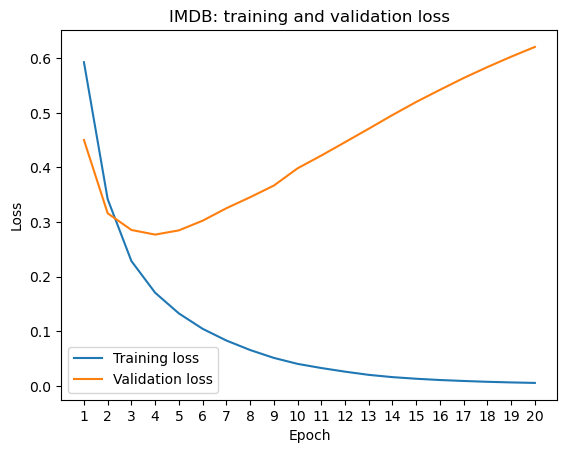

In [15]:
epochs = range(1, len(binary_history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, binary_history.history["loss"], label="Training loss")
plt.plot(epochs, binary_history.history["val_loss"], label="Validation loss")

plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("IMDB: training and validation loss")
plt.legend()
plt.show()

아래 코드는 정확도의 변화를 보여준다.

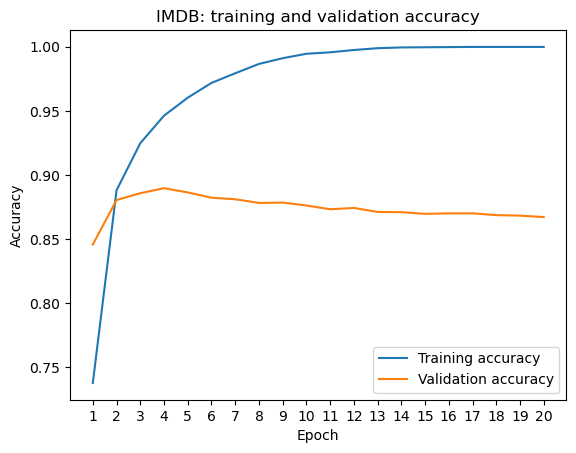

In [16]:
plt.figure()
plt.plot(epochs, binary_history.history["accuracy"], label="Training accuracy")
plt.plot(epochs, binary_history.history["val_accuracy"], label="Validation accuracy")

plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("IMDB: training and validation accuracy")
plt.legend()
plt.show()

그래프를 보고 다음을 확인한다.

- 훈련 손실은 계속 감소하는가?
- 검증 손실은 어느 시점부터 다시 증가하는가?
- 훈련 정확도와 검증 정확도의 차이는 어떻게 변하는가?

> 훈련 성능은 계속 좋아지지만 검증 성능이 더 이상 좋아지지 않거나 나빠지기 시작하면 **과대적합**이 발생하고 있다고 볼 수 있다.

### 테스트 데이터에서 최종 평가

테스트 데이터를 대상으로 훈련된 모델의 성능을 최종 평가한다.
`evaluate()` 메서드는 배치 단위로 평가한 다음에 평균값을 계산한다.
배치 크기는 32가 기본값으로 사용된다.

In [17]:
binary_test_loss, binary_test_acc = binary_model.evaluate(imdb_x_test, imdb_y_test, batch_size=128)

print("test loss:", binary_test_loss)
print("test accuracy:", binary_test_acc)

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8558 - loss: 0.6736
test loss: 0.6736218929290771
test accuracy: 0.8558400273323059


테스트 데이터 10개에 대한 모델 예측값은 다음과 같다.

In [18]:
binary_predictions = binary_model.predict(imdb_x_test[:10]).reshape(-1)

for i, p in enumerate(binary_predictions):
    predicted_label = int(p >= 0.5)
    print(
        f"{i:2d}: probability={p:.3f}, "
        f"prediction={predicted_label}, target={int(imdb_y_test[i])}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
 0: probability=0.011, prediction=0, target=0
 1: probability=1.000, prediction=1, target=1
 2: probability=0.761, prediction=1, target=1
 3: probability=0.948, prediction=1, target=0
 4: probability=0.996, prediction=1, target=1
 5: probability=0.999, prediction=1, target=1
 6: probability=0.988, prediction=1, target=1
 7: probability=0.000, prediction=0, target=0
 8: probability=0.967, prediction=1, target=0
 9: probability=1.000, prediction=1, target=1


## 다중 클래스 분류: Reuters 뉴스 기사

이번에는 뉴스 기사를 **46개의 주제 중 하나**로 분류한다.

- 입력: Reuters 뉴스 기사
- 타깃: `0~45`의 주제 번호
- 문제 유형: **다중 클래스 분류**

P1의 MNIST와 마찬가지로 여러 클래스 중 하나를 선택하지만,
이번에는 이미지가 아니라 벡터화된 텍스트를 입력으로 사용한다.

**Reuters 데이터 불러오기**

In [19]:
from keras.datasets import reuters

(reuters_train_data, reuters_train_labels), (reuters_test_data, reuters_test_labels) = reuters.load_data(num_words=10000)

print("훈련 샘플 수:", len(reuters_train_data))
print("테스트 샘플 수:", len(reuters_test_data))
print("클래스 수:", np.max(reuters_train_labels) + 1)

훈련 샘플 수: 8982
테스트 샘플 수: 2246
클래스 수: 46


### 입력 데이터 벡터화

In [21]:
rx_train = multi_hot_encode(reuters_train_data)
rx_test = multi_hot_encode(reuters_test_data)


In [25]:
rx_train = multi_hot_encode(reuters_train_data)
rx_test = multi_hot_encode(reuters_test_data)

# 타깃은 정수형으로 변환
ry_train = np.asarray(reuters_train_labels, dtype="int64")
ry_test = np.asarray(reuters_test_labels, dtype="int64")

print("입력 shape:", rx_train.shape)
print("타깃 shape:", ry_train.shape)
print("타깃 예:", ry_train[:10])

입력 shape: (8982, 10000)
타깃 shape: (8982,)
타깃 예: [ 3  4  3  4  4  4  4  3  3 16]


### 훈련셋과 검증셋 분리

훈련 데이터셋 자체가 그리 크지 않기에 1000개 정도만 검증용으로 지정한다.

In [26]:
rx_val = rx_train[:1000]
partial_rx_train = rx_train[1000:]

ry_val = ry_train[:1000]
partial_ry_train = ry_train[1000:]

print("실제 훈련셋:", partial_rx_train.shape)
print("검증셋:", rx_val.shape)

실제 훈련셋: (7982, 10000)
검증셋: (1000, 10000)


### 다중 클래스 분류 모델 구성

여기서도 2개의 은닉층을 사용한다.

다만 은닉층의 유닛 개수를 범주의 개수인 46보다 큰 수를 지정하기 위해 64로 지정한다.

**Top-3 정확도**

평가지표로 추가된 Top-3 accuracy는 모델이 예측한 확률이 높은 상위 3개 클래스 안에 정답 클래스가 포함된 비율이다.

클래스 수가 많은 경우 일반 accuracy는 모델의 예측 정보를 충분히 반영하지 못할 수 있으므로, 정답이 상위 3개 예측에 포함되는지를 나타내는 Top-3 accuracy를 함께 사용한다.

In [27]:
top_3_accuracy = keras.metrics.SparseTopKCategoricalAccuracy(
    k=3,
    name="top_3_accuracy"
)

multiclass_model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

multiclass_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy]
)

입력 데이터 샘플의 길이를 지정하면 모델의 구조를 확인할 수 있다.

In [28]:
multiclass_model.build(input_shape=(None, 10000))
multiclass_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

출력층은 클래스 수와 같은 46개의 유닛을 사용한다.

```python
Dense(46, activation="softmax")
```

각 샘플에 대해 46개 클래스의 확률이 출력되며,
이 값들의 합은 1이다.

타깃을 정수 범주 그대로 사용했으므로
`sparse_categorical_crossentropy`를 사용한다.

### 모델 훈련

In [ ]:
multiclass_history = multiclass_model.fit(
    partial_rx_train,
    partial_ry_train,
    epochs=20,
    batch_size=512,
    validation_data=(rx_val, ry_val),
    verbose=1
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 288ms/step - accuracy: 0.3405 - loss: 3.2841 - top_3_accuracy: 0.5596 - val_accuracy: 0.5970 - val_loss: 2.4449 - val_top_3_accuracy: 0.7060
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6376 - loss: 1.8794 - top_3_accuracy: 0.7531 - val_accuracy: 0.6740 - val_loss: 1.5361 - val_top_3_accuracy: 0.7750
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7335 - loss: 1.2522 - top_3_accuracy: 0.8251 - val_accuracy: 0.7350 - val_loss: 1.2317 - val_top_3_accuracy: 0.8330
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7922 - loss: 0.9585 - top_3_accuracy: 0.8773 - val_accuracy: 0.7610 - val_loss: 1.1000 - val_top_3_accuracy: 0.8540
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8369 - loss: 0.7546 - top_3_accuracy: 0.9201 - val_accuracy: 0.7810 - val_loss: 1.0193 - val_top_3_accuracy: 0.8790
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8768 - loss: 0.5942 - top_3_accura

### 훈련 과정 확인

아래 코드는 손실값의 변화를 보여준다.

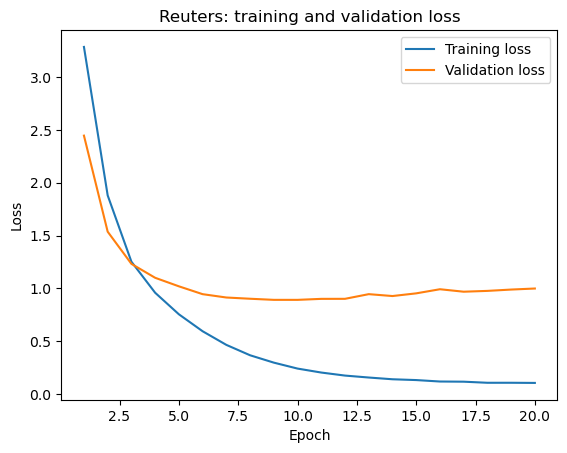

In [30]:
mc_epochs = range(1, len(multiclass_history.history["loss"]) + 1)

plt.figure()
plt.plot(mc_epochs, multiclass_history.history["loss"], label="Training loss")
plt.plot(mc_epochs, multiclass_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reuters: training and validation loss")
plt.legend()
plt.show()

정확도의 변화는 다음과 같다.

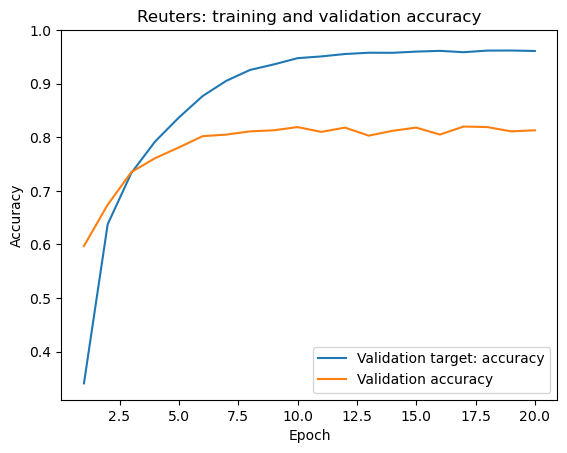

In [31]:
plt.figure()
plt.plot(mc_epochs, multiclass_history.history["accuracy"], label="Validation target: accuracy")
plt.plot(mc_epochs, multiclass_history.history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.31, 1)
plt.title("Reuters: training and validation accuracy")
plt.legend()
plt.show()

`accuracy`는 정답 클래스가 **가장 높은 확률을 가진 클래스인지**만 확인한다.

Reuters처럼 클래스 수가 많은 경우에는 정답이 상위 몇 개의 후보 안에 포함되었는지도 확인할 수 있다.
여기서는 `top_3_accuracy`를 함께 기록했다.

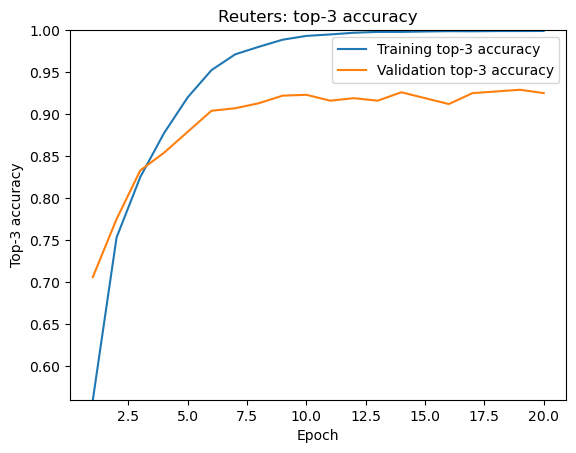

In [32]:
plt.figure()
plt.plot(
    mc_epochs,
    multiclass_history.history["top_3_accuracy"],
    label="Training top-3 accuracy"
)
plt.plot(
    mc_epochs,
    multiclass_history.history["val_top_3_accuracy"],
    label="Validation top-3 accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Top-3 accuracy")
plt.ylim(0.56, 1)
plt.title("Reuters: top-3 accuracy")
plt.legend()
plt.show()

### 다중 클래스 분류 모델 예측값 확인

소프트맥스 활성화 함수는 각 범주에 속할 확률로 구성된 어레이를 예측값으로 반환한다.
또한 모든 확률의 합은 1이며, 그 중에 가장 큰 확률이 위치한 인덱스가 예측 범주로 지정된다.

In [34]:
mc_predictions = multiclass_model.predict(rx_test[:3], verbose=0)

print("한 샘플의 출력 shape:", mc_predictions[0].shape)
print("확률 합:", mc_predictions[0].sum())
print("예측 범주:", mc_predictions[0].argmax())
print("실제 범주:", ry_test[0])

한 샘플의 출력 shape: (46,)
확률 합: 1.0
예측 범주: 3
실제 범주: 3


### 테스트 데이터에서 최종 평가

In [33]:
mc_results = multiclass_model.evaluate(rx_test, ry_test, verbose=0)

print("test loss:", mc_results[0])
print("test accuracy:", mc_results[1])
print("test top-3 accuracy:", mc_results[2])

test loss: 1.119246482849121
test accuracy: 0.7871772050857544
test top-3 accuracy: 0.9065004587173462


## 회귀: California Housing

분류에서는 범주를 예측했지만 회귀에서는 **연속적인 수치**를 예측한다.

California Housing 데이터셋에서는 지역의 인구·소득·주택 관련 특성을 이용하여
**중위 주택가격**을 예측한다.

**California Housing 데이터 불러오기**

In [27]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

housing_X = housing.data.astype("float32")
housing_y = housing.target.astype("float32")

print("입력 shape:", housing_X.shape)
print("타깃 shape:", housing_y.shape)
print("특성 이름:", housing.feature_names)
print("타깃 예:", housing_y[:5])

입력 shape: (20640, 8)
타깃 shape: (20640,)
특성 이름: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
타깃 예: [4.526 3.585 3.521 3.413 3.422]


In [60]:
housing_X[0][0]

np.float32(8.3252)

특성 변수중에 중위 소득(`MedInc`)는 1만 달러 단위로 저장되어 있다.
예를 들어 중위소득 `8.3252`는 83,252 달러를 의미한다.

반면에 `target`은 지역별 중위 주택가격을 나타내며 **10만 달러 단위**로 저장되어 있다.
예를 들어 타깃이 `2.5`라면 약 25만 달러를 의미한다.

### 훈련셋, 검증셋, 테스트셋 분리

이진 분류와 다중 클래스 분류에서와 마찬가지로
훈련 과정에서는 **훈련셋과 검증셋**을 사용하고,
테스트셋은 **최종 평가**에만 사용한다.

In [28]:
housing_X_train_full, housing_X_test, housing_y_train_full, housing_y_test = train_test_split(
    housing_X,
    housing_y,
    test_size=0.2,
    random_state=42
)

housing_X_train, housing_X_val, housing_y_train, housing_y_val = train_test_split(
    housing_X_train_full,
    housing_y_train_full,
    test_size=0.2,
    random_state=42
)

print("훈련셋:", housing_X_train.shape)
print("검증셋:", housing_X_val.shape)
print("테스트셋:", housing_X_test.shape)

훈련셋: (13209, 8)
검증셋: (3303, 8)
테스트셋: (4128, 8)


### 입력 특성 표준화

California Housing의 입력 특성들은 서로 다른 범위의 값을 가진다.
예를 들어 위도와 경도, 중위소득, 평균 방 수는 값의 범위와 단위가 서로 다르다.

따라서 훈련셋의 평균과 표준편차를 이용하여 입력 특성을 표준화한다.

> **표준화 기준은 훈련셋에서만 계산하고, 검증셋과 테스트셋에는 같은 기준을 적용한다.**

In [29]:
housing_scaler = StandardScaler()

housing_X_train_scaled = housing_scaler.fit_transform(
    housing_X_train
).astype("float32")

housing_X_val_scaled = housing_scaler.transform(
    housing_X_val
).astype("float32")

housing_X_test_scaled = housing_scaler.transform(
    housing_X_test
).astype("float32")

### 회귀 모델 구성

분류 모델과 마찬가지로 두 개의 은닉층을 사용한다.
여기서는 각 은닉층에 64개의 유닛을 사용한다.

회귀에서는 하나의 연속적인 수치를 예측하므로 출력층은 유닛 1개를 사용하고
활성화 함수를 지정하지 않는다.

```text
Dense(1)
```

손실함수는 평균제곱오차(MSE)를 사용하고,
평가지표는 평균제곱근오차(RMSE)를 사용한다.
RMSE는 타깃과 같은 단위를 사용하므로 예측 오차의 크기를 해석하기 쉽다.

In [30]:
regression_model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

regression_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

모델의 구조는 다음과 같다.

In [31]:
regression_model.build(input_shape=(None, housing_X_train_scaled.shape[1]))
regression_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

### 모델 훈련

In [32]:
regression_history = regression_model.fit(
    housing_X_train_scaled,
    housing_y_train,
    epochs=50,
    batch_size=64,
    validation_data=(housing_X_val_scaled, housing_y_val),
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.3302 - rmse: 1.1533 - val_loss: 0.6195 - val_rmse: 0.7871
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4568 - rmse: 0.6759 - val_loss: 0.4384 - val_rmse: 0.6621
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3856 - rmse: 0.6210 - val_loss: 0.3944 - val_rmse: 0.6280
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3644 - rmse: 0.6037 - val_loss: 0.4157 - val_rmse: 0.6448
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3514 - rmse: 0.5928 - val_loss: 0.4009 - val_rmse: 0.6332
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3421 - rmse: 0.5849 - val_loss: 0.3712 - val_rmse: 0.6093
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3320 - rmse: 0.5762 - val_loss: 0.4004 - val_rmse: 0.6328
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3239 - rmse: 0.5691 - val_loss: 0.4113 - val_rmse: 0.6413
Epoch 9/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 

### 훈련 과정 확인

먼저 손실값(MSE)의 변화를 확인한다.

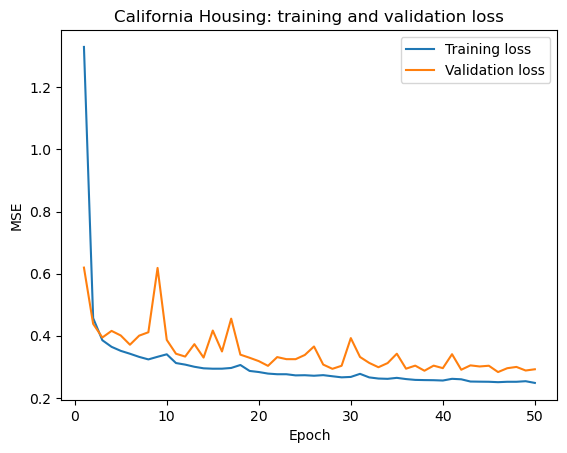

In [33]:
reg_epochs = range(1, len(regression_history.history["loss"]) + 1)

plt.figure()
plt.plot(reg_epochs, regression_history.history["loss"], label="Training loss")
plt.plot(reg_epochs, regression_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("California Housing: training and validation loss")
plt.legend()
plt.show()

평가지표인 RMSE의 변화도 확인한다.

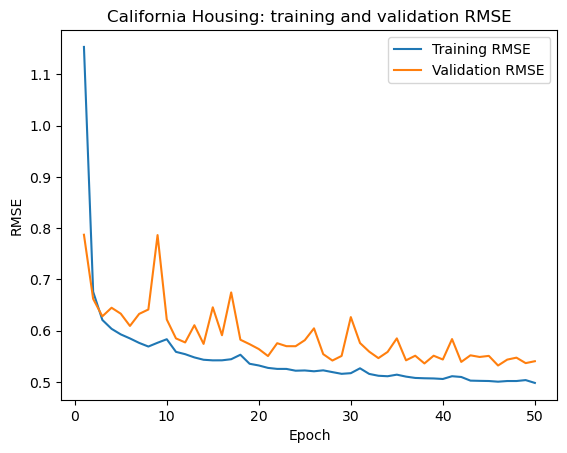

In [34]:
plt.figure()
plt.plot(reg_epochs, regression_history.history["rmse"], label="Training RMSE")
plt.plot(reg_epochs, regression_history.history["val_rmse"], label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("California Housing: training and validation RMSE")
plt.legend()
plt.show()

그래프를 보고 다음을 확인한다.

- 훈련 RMSE는 계속 감소하는가?
- 검증 RMSE는 어느 시점부터 더 이상 좋아지지 않는가?
- 훈련 RMSE와 검증 RMSE의 차이는 어떻게 변하는가?

분류 문제에서와 마찬가지로
**훈련 성능과 검증 성능의 차이**를 이용하여 일반화 상태를 확인할 수 있다.

### 테스트 데이터에서 최종 평가

In [35]:
reg_test_mse, reg_test_rmse = regression_model.evaluate(
    housing_X_test_scaled,
    housing_y_test,
    verbose=0
)

print("test MSE:", reg_test_mse)
print("test RMSE:", reg_test_rmse)
print("달러 기준 RMSE(대략):", reg_test_rmse * 100000)

test MSE: 0.2895983159542084
test RMSE: 0.5381433963775635
달러 기준 RMSE(대략): 53814.33963775635


### 실제값과 예측값 비교

In [36]:
reg_predictions = regression_model.predict(
    housing_X_test_scaled[:10],
    verbose=0
).reshape(-1)

for actual, predicted in zip(housing_y_test[:10], reg_predictions):
    print(
        f"actual={actual:.3f}, "
        f"predicted={predicted:.3f}, "
        f"error={predicted - actual:+.3f}"
    )

actual=0.477, predicted=0.511, error=+0.034
actual=0.458, predicted=1.139, error=+0.681
actual=5.000, predicted=4.544, error=-0.456
actual=2.186, predicted=2.431, error=+0.245
actual=2.780, predicted=2.517, error=-0.263
actual=1.587, predicted=1.525, error=-0.062
actual=1.982, predicted=2.411, error=+0.429
actual=1.575, predicted=1.574, error=-0.001
actual=3.400, predicted=2.314, error=-1.086
actual=4.466, predicted=4.279, error=-0.187


## 모델 평가: 홀드아웃과 교차 검증

앞의 세 문제에서는 훈련 데이터의 일부를 검증셋으로 따로 두는
**홀드아웃 검증**(hold-out validation)을 사용했다.

교차 검증은 회귀에만 사용하는 방법이 아니다.
**분류와 회귀 모두에서** 하나의 검증셋에만 의존하지 않고
모델의 일반화 성능을 보다 안정적으로 평가하기 위해 사용할 수 있다.

이번 실습에서는 California Housing 데이터를 이용하여
**3겹 교차 검증**(3-fold cross-validation)을 적용해 본다.

### 3겹 교차 검증

훈련 데이터를 세 부분으로 나눈 뒤,

> **2개 fold로 훈련 → 남은 1개 fold로 검증**

하는 과정을 세 번 반복한다.

각 fold가 한 번씩 검증 데이터가 되며,
세 번의 검증 RMSE를 평균하여 모델의 일반화 성능을 평가한다.

테스트셋은 교차 검증 과정에서도 사용하지 않는다.

In [37]:
from sklearn.model_selection import KFold

def build_regression_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

    return model


kfold = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

fold_rmse = []

for fold, (train_idx, val_idx) in enumerate(
    kfold.split(housing_X_train_full),
    start=1
):
    fold_X_train = housing_X_train_full[train_idx]
    fold_y_train = housing_y_train_full[train_idx]

    fold_X_val = housing_X_train_full[val_idx]
    fold_y_val = housing_y_train_full[val_idx]

    # 표준화 기준은 각 fold의 훈련 데이터에서만 계산
    fold_scaler = StandardScaler()
    fold_X_train_scaled = fold_scaler.fit_transform(
        fold_X_train
    ).astype("float32")
    fold_X_val_scaled = fold_scaler.transform(
        fold_X_val
    ).astype("float32")

    fold_model = build_regression_model()

    fold_model.fit(
        fold_X_train_scaled,
        fold_y_train,
        epochs=50,
        batch_size=64,
        verbose=0
    )

    _, val_rmse = fold_model.evaluate(
        fold_X_val_scaled,
        fold_y_val,
        verbose=0
    )

    fold_rmse.append(val_rmse)
    print(f"fold {fold} RMSE: {val_rmse:.4f}")

print()
print(f"평균 validation RMSE: {np.mean(fold_rmse):.4f}")
print(f"validation RMSE 표준편차: {np.std(fold_rmse):.4f}")

fold 1 RMSE: 0.5368
fold 2 RMSE: 0.5281
fold 3 RMSE: 0.5389

평균 validation RMSE: 0.5346
validation RMSE 표준편차: 0.0047


홀드아웃 검증은 한 번의 분할 결과를 사용하지만,
K-fold 교차 검증은 서로 다른 검증셋에서 얻은 결과를 평균한다.

따라서 데이터가 많지 않거나 하나의 분할 결과에 민감할 수 있는 경우
교차 검증을 이용하면 모델의 일반화 성능을 보다 안정적으로 평가할 수 있다.

분류 문제에도 같은 원리를 적용할 수 있으며,
클래스 비율을 유지해야 하는 경우에는 `StratifiedKFold`를 사용할 수 있다.

## Keras에서 훈련 과정 관리하기: 콜백

Keras의 `fit()`은 모델 훈련을 내부에서 수행하지만,
훈련 과정에서 계산되는 손실값과 평가지표를 관찰하고
필요한 동작을 실행하도록 **콜백**(callback)을 지정할 수 있다.

P2에서는 일반화 성능을 확인하고 과대적합에 대응하기 위해 다음 콜백을 사용한다.

- `EarlyStopping`: 검증 성능이 더 이상 개선되지 않으면 훈련을 종료
- `ModelCheckpoint`: 훈련 중 가장 좋은 성능의 모델을 저장
- `ReduceLROnPlateau`: 검증 성능이 정체되면 학습률을 줄임

콜백은 `fit()`의 `callbacks` 인자로 전달한다.

### EarlyStopping과 ModelCheckpoint

먼저 IMDB 이진 분류 모델에 두 콜백을 함께 적용한다.

`EarlyStopping`은 검증 손실이 더 이상 좋아지지 않으면 훈련을 멈추고,
`ModelCheckpoint`는 검증 손실이 가장 낮았던 모델을 파일로 저장한다.

In [38]:
checkpoint_path = "p2_imdb_best_model.keras"

callback_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

callback_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
    ),
]

callback_history = callback_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7314 - loss: 0.5806 - val_accuracy: 0.8515 - val_loss: 0.4385
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8960 - loss: 0.3339 - val_accuracy: 0.8846 - val_loss: 0.3110
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9265 - loss: 0.2246 - val_accuracy: 0.8828 - val_loss: 0.2898
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9467 - loss: 0.1709 - val_accuracy: 0.8884 - val_loss: 0.2811
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9613 - loss: 0.1320 - val_accuracy: 0.8863 - val_loss: 0.2853
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9721 - loss: 0.1042 - val_accuracy: 0.8833 - val_loss: 0.3013


`epochs=20`은 최대 훈련 횟수다.
검증 손실이 더 이상 개선되지 않으면 실제 훈련은 그보다 일찍 종료될 수 있다.

`restore_best_weights=True`를 사용하면 훈련이 종료된 뒤
검증 손실이 가장 좋았던 시점의 가중치로 되돌아간다.

`ModelCheckpoint`는 같은 시점의 전체 모델을 파일로 저장할 수 있다.

In [39]:
best_model = keras.models.load_model(checkpoint_path)

best_test_loss, best_test_acc = best_model.evaluate(
    imdb_x_test,
    imdb_y_test,
    verbose=0,
)

print("best model test loss:", best_test_loss)
print("best model test accuracy:", best_test_acc)

best model test loss: 0.30206385254859924
best model test accuracy: 0.8769999742507935


### 학습률 조정

검증 손실이 일정 기간 개선되지 않을 때
학습률을 줄이는 방법도 사용할 수 있다.

`ReduceLROnPlateau`는 모델이 현재 학습률에서 더 이상 충분히 개선되지 않을 때
학습률을 자동으로 낮춘다.

In [40]:
lr_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

lr_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lr_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
]

lr_history = lr_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    callbacks=lr_callbacks,
    verbose=1,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7459 - loss: 0.5603 - val_accuracy: 0.8550 - val_loss: 0.4097 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9003 - loss: 0.3072 - val_accuracy: 0.8869 - val_loss: 0.3020 - learning_rate: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9330 - loss: 0.2093 - val_accuracy: 0.8907 - val_loss: 0.2777 - learning_rate: 0.0010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9527 - loss: 0.1578 - val_accuracy: 0.8878 - val_loss: 0.2776 - learning_rate: 0.0010
Epoch 5/20
14/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9707 - loss: 0.1215 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9655 - loss: 0.1227 - val_accuracy: 0.8838 - val_loss: 0.2885 - learning_rate: 0.0010
Epoch 6/20
16/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9791 - loss: 0.1010 
Epoch 6: Redu

## 일반화: IMDB 모델 다시 살펴보기

앞의 IMDB 모델에서 훈련 성능과 검증 성능의 차이가 커지는 현상을 관찰했다.

이번에는 같은 문제에 다음 세 방법을 적용한다.

- **L2 가중치 규제**: 큰 가중치에 패널티를 주어 모델이 지나치게 복잡한 표현에 의존하지 않도록 한다.
- **드롭아웃**: 훈련 중 일부 유닛의 출력을 무작위로 0으로 만들어 과도한 적응을 방해한다.
- **조기 종료**: 검증 성능이 더 이상 좋아지지 않으면 훈련을 멈춘다.

먼저 L2 가중치 규제를 단독으로 적용한 뒤,
드롭아웃과 조기 종료를 적용한 모델과 비교한다.

### L2 가중치 규제

**L2 가중치 규제**(L2 weight regularization)는
큰 가중치에 비용을 추가하여 가중치가 지나치게 커지는 것을 억제한다.

기본 손실함수가 $L$이고 가중치가 $w$라면,
L2 규제를 적용한 손실은 다음과 같이 생각할 수 있다.

$$L_{regularized} = L + \lambda \sum_i w_i^2$$

여기서 $\lambda$는 규제의 강도를 조절하는 값이다.

Keras에서는 `kernel_regularizer`를 이용하여 층의 가중치에
L2 규제를 적용할 수 있다.

In [41]:
from keras import regularizers

l2_model = keras.Sequential([
    layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.002)
    ),
    layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.002)
    ),
    layers.Dense(1, activation="sigmoid")
])

l2_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

l2_history = l2_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7129 - loss: 0.6590 - val_accuracy: 0.8552 - val_loss: 0.5256
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8902 - loss: 0.4355 - val_accuracy: 0.8768 - val_loss: 0.4136
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9153 - loss: 0.3459 - val_accuracy: 0.8822 - val_loss: 0.3830
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9287 - loss: 0.3044 - val_accuracy: 0.8862 - val_loss: 0.3706
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9395 - loss: 0.2812 - val_accuracy: 0.8835 - val_loss: 0.3700
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9461 - loss: 0.2625 - val_accuracy: 0.8817 - val_loss: 0.3726
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9515 - loss: 0.2497 - val_accuracy: 0.8808 - val_loss: 0.3820
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9547 - loss: 0.2396 - val_accuracy: 0.8789 - val_loss

L2 규제를 적용해도 훈련 데이터에 대한 손실을 줄이는 것이 목표이지만,
동시에 큰 가중치에 대한 패널티가 추가된다.

따라서 기본 모델보다 훈련 손실이 더 높을 수 있으며,
중요한 것은 **검증 손실이 언제부터 증가하는지와 증가 정도가 어떻게 달라지는지** 확인하는 것이다.

### 기본 모델과 L2 규제 모델의 검증 손실 비교

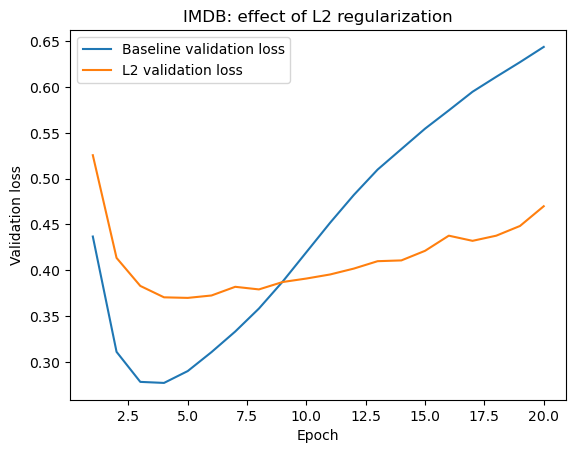

In [42]:
plt.figure()

plt.plot(
    range(1, len(binary_history.history["val_loss"]) + 1),
    binary_history.history["val_loss"],
    label="Baseline validation loss"
)

plt.plot(
    range(1, len(l2_history.history["val_loss"]) + 1),
    l2_history.history["val_loss"],
    label="L2 validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("IMDB: effect of L2 regularization")
plt.legend()
plt.show()

### 드롭아웃을 적용한 모델

In [43]:
regularized_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

regularized_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_imdb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

regularized_history = regularized_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    callbacks=[early_stopping_imdb],
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5583 - loss: 0.6802 - val_accuracy: 0.7809 - val_loss: 0.6264
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7061 - loss: 0.5807 - val_accuracy: 0.8531 - val_loss: 0.4831
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7848 - loss: 0.4845 - val_accuracy: 0.8769 - val_loss: 0.3891
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8325 - loss: 0.4076 - val_accuracy: 0.8846 - val_loss: 0.3265
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8656 - loss: 0.3539 - val_accuracy: 0.8874 - val_loss: 0.2974
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8867 - loss: 0.3065 - val_accuracy: 0.8893 - val_loss: 0.2790
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9034 - loss: 0.2795 - val_accuracy: 0.8896 - val_loss: 0.2758
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9197 - loss: 0.2460 - val_accuracy: 0.8906 - val_loss

### 기본 모델, L2 규제 모델, 드롭아웃 모델 비교

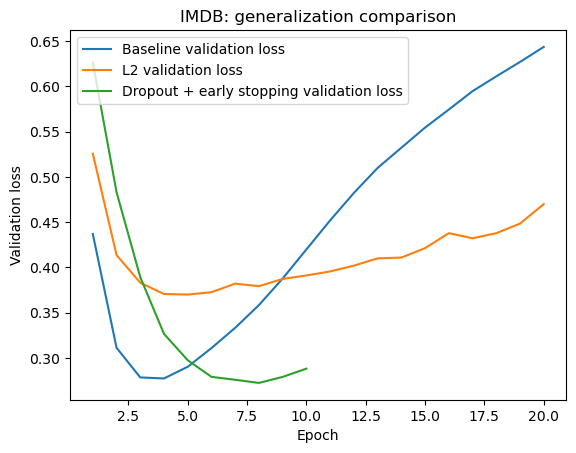

In [44]:
plt.figure()

plt.plot(
    range(1, len(binary_history.history["val_loss"]) + 1),
    binary_history.history["val_loss"],
    label="Baseline validation loss"
)

plt.plot(
    range(1, len(l2_history.history["val_loss"]) + 1),
    l2_history.history["val_loss"],
    label="L2 validation loss"
)

plt.plot(
    range(1, len(regularized_history.history["val_loss"]) + 1),
    regularized_history.history["val_loss"],
    label="Dropout + early stopping validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("IMDB: generalization comparison")
plt.legend()
plt.show()

### 규제 모델의 테스트 성능

In [45]:
l2_test_loss, l2_test_acc = l2_model.evaluate(
    imdb_x_test, imdb_y_test, verbose=0
)

reg_binary_test_loss, reg_binary_test_acc = regularized_model.evaluate(
    imdb_x_test, imdb_y_test, verbose=0
)

print("baseline test accuracy:", binary_test_acc)
print("L2 test accuracy:", l2_test_acc)
print("dropout + early stopping test accuracy:", reg_binary_test_acc)

baseline test accuracy: 0.855400025844574
L2 test accuracy: 0.8569999933242798
dropout + early stopping test accuracy: 0.8845599889755249


## PyTorch로 일반화 확인하기

앞에서는 Keras를 이용하여 IMDB 모델의 과대적합을 확인하고
L2 가중치 규제, 드롭아웃, 조기 종료를 적용했다.

같은 과정을 PyTorch에서도 직접 구현할 수 있다.

PyTorch에서는 Keras의 `fit()`과 callback이 처리하던 과정을
훈련 루프 안에서 명시적으로 구현한다.

이번에는 다음 순서로 진행한다.

> **DataLoader 준비 → 기본 모델 훈련 → 검증 손실 확인 → L2 가중치 규제 → 드롭아웃 적용 → 조기 종료 구현 → 테스트 평가**

### PyTorch용 데이터 준비

In [46]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# NumPy 배열을 PyTorch tensor로 변환
imdb_train_tensor = torch.tensor(imdb_partial_x_train, dtype=torch.float32)
imdb_train_target = torch.tensor(imdb_partial_y_train, dtype=torch.float32)

imdb_val_tensor = torch.tensor(imdb_x_val, dtype=torch.float32)
imdb_val_target = torch.tensor(imdb_y_val, dtype=torch.float32)

imdb_test_tensor = torch.tensor(imdb_x_test, dtype=torch.float32)
imdb_test_target = torch.tensor(imdb_y_test, dtype=torch.float32)

# BCEWithLogitsLoss에 맞게 타깃 shape을 (N, 1)로 맞춘다.
imdb_train_target = imdb_train_target.unsqueeze(1)
imdb_val_target = imdb_val_target.unsqueeze(1)
imdb_test_target = imdb_test_target.unsqueeze(1)

train_dataset = TensorDataset(imdb_train_tensor, imdb_train_target)
val_dataset = TensorDataset(imdb_val_tensor, imdb_val_target)
test_dataset = TensorDataset(imdb_test_tensor, imdb_test_target)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512)
test_loader = DataLoader(test_dataset, batch_size=512)

print("훈련 배치 수:", len(train_loader))
print("검증 배치 수:", len(val_loader))
print("테스트 배치 수:", len(test_loader))

device: cuda
훈련 배치 수: 30
검증 배치 수: 20
테스트 배치 수: 49


### 기본 PyTorch 모델

Keras의

```python
Dense(16, relu) → Dense(16, relu) → Dense(1, sigmoid)
```

와 대응되는 구조를 사용한다.

PyTorch에서는 `BCEWithLogitsLoss()`를 사용하므로
마지막 층에 sigmoid를 넣지 않는다.

In [47]:
class ImdbMLP(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10000, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

### 한 에포크 훈련 함수

In [48]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

### 검증 함수

In [49]:
def evaluate_binary(model, loader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            running_loss += loss.item() * x_batch.size(0)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### 기본 모델 훈련

In [50]:
torch_baseline = ImdbMLP(dropout_rate=0.0).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_baseline.parameters())

torch_baseline_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        torch_baseline,
        train_loader,
        loss_fn,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate_binary(
        torch_baseline,
        val_loader,
        loss_fn,
        device,
    )

    torch_baseline_history["loss"].append(train_loss)
    torch_baseline_history["accuracy"].append(train_acc)
    torch_baseline_history["val_loss"].append(val_loss)
    torch_baseline_history["val_accuracy"].append(val_acc)

    print(
        f"epoch {epoch + 1:2d}: "
        f"loss={train_loss:.4f}, "
        f"accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_accuracy={val_acc:.4f}"
    )

epoch  1: loss=0.6441, accuracy=0.6997, val_loss=0.5647, val_accuracy=0.8303
epoch  2: loss=0.4585, accuracy=0.8759, val_loss=0.3898, val_accuracy=0.8714
epoch  3: loss=0.3005, accuracy=0.9081, val_loss=0.3059, val_accuracy=0.8845
epoch  4: loss=0.2181, accuracy=0.9310, val_loss=0.2791, val_accuracy=0.8922
epoch  5: loss=0.1712, accuracy=0.9467, val_loss=0.2756, val_accuracy=0.8913
epoch  6: loss=0.1373, accuracy=0.9587, val_loss=0.2810, val_accuracy=0.8890
epoch  7: loss=0.1124, accuracy=0.9679, val_loss=0.2916, val_accuracy=0.8859
epoch  8: loss=0.0922, accuracy=0.9757, val_loss=0.3137, val_accuracy=0.8821
epoch  9: loss=0.0751, accuracy=0.9819, val_loss=0.3278, val_accuracy=0.8815
epoch 10: loss=0.0616, accuracy=0.9867, val_loss=0.3529, val_accuracy=0.8784
epoch 11: loss=0.0500, accuracy=0.9908, val_loss=0.3750, val_accuracy=0.8770
epoch 12: loss=0.0406, accuracy=0.9934, val_loss=0.3977, val_accuracy=0.8759
epoch 13: loss=0.0327, accuracy=0.9957, val_loss=0.4226, val_accuracy=0.8761

### 기본 모델의 훈련·검증 곡선

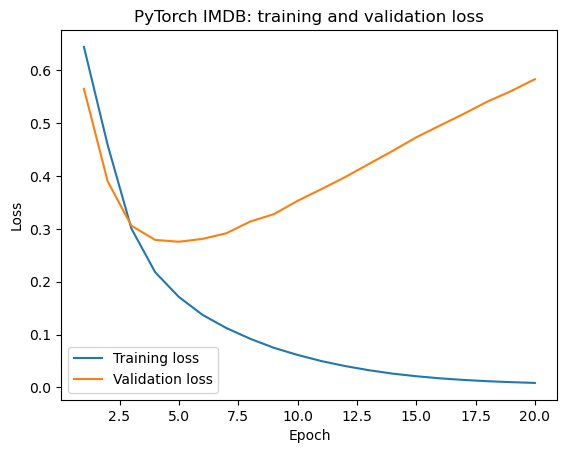

In [51]:
torch_epochs = range(1, len(torch_baseline_history["loss"]) + 1)

plt.figure()
plt.plot(torch_epochs, torch_baseline_history["loss"], label="Training loss")
plt.plot(torch_epochs, torch_baseline_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch IMDB: training and validation loss")
plt.legend()
plt.show()

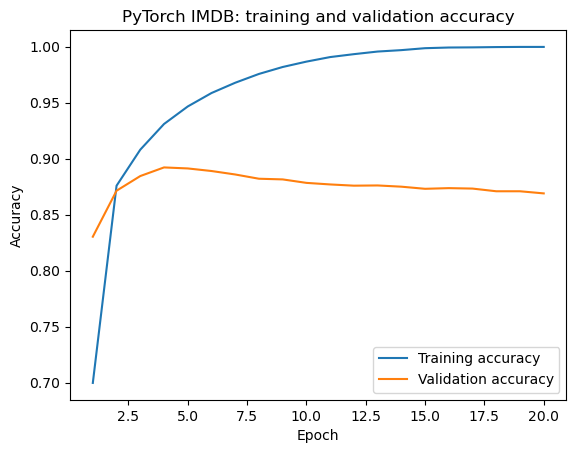

In [52]:
plt.figure()
plt.plot(torch_epochs, torch_baseline_history["accuracy"], label="Training accuracy")
plt.plot(torch_epochs, torch_baseline_history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch IMDB: training and validation accuracy")
plt.legend()
plt.show()

훈련 손실은 계속 감소하지만 검증 손실이 다시 증가하기 시작한다면
Keras에서와 마찬가지로 과대적합이 나타나고 있다고 볼 수 있다.

### PyTorch에서 L2 가중치 규제 적용

PyTorch에서는 optimizer의 `weight_decay`를 이용하여
L2 규제에 해당하는 가중치 감쇠를 적용하는 방법이 널리 사용된다.

여기서는 기본 모델과 같은 구조를 사용하고
`Adam(..., weight_decay=0.002)`를 적용한다.

In [53]:
torch_l2 = ImdbMLP(dropout_rate=0.0).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    torch_l2.parameters(),
    weight_decay=0.002
)

torch_l2_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        torch_l2,
        train_loader,
        loss_fn,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate_binary(
        torch_l2,
        val_loader,
        loss_fn,
        device,
    )

    torch_l2_history["loss"].append(train_loss)
    torch_l2_history["accuracy"].append(train_acc)
    torch_l2_history["val_loss"].append(val_loss)
    torch_l2_history["val_accuracy"].append(val_acc)

    print(
        f"epoch {epoch + 1:2d}: "
        f"loss={train_loss:.4f}, "
        f"accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_accuracy={val_acc:.4f}"
    )

epoch  1: loss=0.6333, accuracy=0.7567, val_loss=0.5455, val_accuracy=0.8590
epoch  2: loss=0.4375, accuracy=0.8819, val_loss=0.3680, val_accuracy=0.8742
epoch  3: loss=0.2889, accuracy=0.9064, val_loss=0.3002, val_accuracy=0.8845
epoch  4: loss=0.2220, accuracy=0.9269, val_loss=0.2831, val_accuracy=0.8870
epoch  5: loss=0.1868, accuracy=0.9407, val_loss=0.2871, val_accuracy=0.8843
epoch  6: loss=0.1632, accuracy=0.9479, val_loss=0.2873, val_accuracy=0.8834
epoch  7: loss=0.1461, accuracy=0.9569, val_loss=0.2940, val_accuracy=0.8832
epoch  8: loss=0.1328, accuracy=0.9607, val_loss=0.3048, val_accuracy=0.8806
epoch  9: loss=0.1196, accuracy=0.9664, val_loss=0.3101, val_accuracy=0.8788
epoch 10: loss=0.1095, accuracy=0.9719, val_loss=0.3231, val_accuracy=0.8775
epoch 11: loss=0.0991, accuracy=0.9749, val_loss=0.3305, val_accuracy=0.8771
epoch 12: loss=0.0923, accuracy=0.9768, val_loss=0.3397, val_accuracy=0.8755
epoch 13: loss=0.0858, accuracy=0.9807, val_loss=0.3512, val_accuracy=0.8728

### PyTorch 기본 모델과 L2 규제 모델 비교

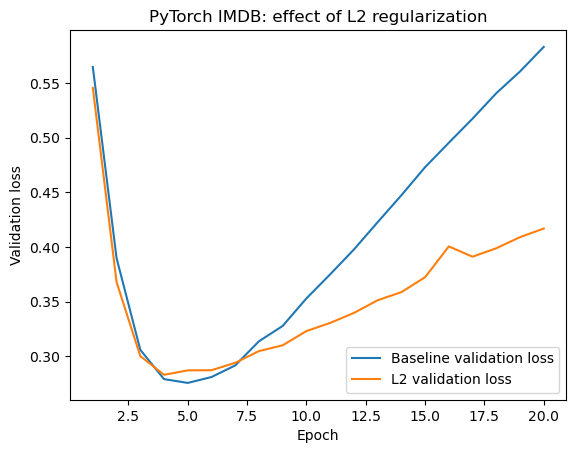

In [54]:
plt.figure()

plt.plot(
    range(1, len(torch_baseline_history["val_loss"]) + 1),
    torch_baseline_history["val_loss"],
    label="Baseline validation loss",
)

plt.plot(
    range(1, len(torch_l2_history["val_loss"]) + 1),
    torch_l2_history["val_loss"],
    label="L2 validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("PyTorch IMDB: effect of L2 regularization")
plt.legend()
plt.show()

### 드롭아웃과 조기 종료 적용

PyTorch에서는 Keras의 `EarlyStopping`과 같은 동작을
훈련 루프에서 직접 구현할 수 있다.

다음 값을 직접 관리한다.

- 현재까지 가장 낮은 검증 손실
- 검증 손실이 개선되지 않은 에포크 수
- 가장 좋은 시점의 모델 파라미터

검증 손실이 `patience`만큼 연속해서 개선되지 않으면 훈련을 종료한다.

In [55]:
import copy

torch_regularized = ImdbMLP(dropout_rate=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_regularized.parameters())

patience = 2
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

torch_regularized_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

max_epochs = 20

for epoch in range(max_epochs):
    train_loss, train_acc = train_one_epoch(
        torch_regularized,
        train_loader,
        loss_fn,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate_binary(
        torch_regularized,
        val_loader,
        loss_fn,
        device,
    )

    torch_regularized_history["loss"].append(train_loss)
    torch_regularized_history["accuracy"].append(train_acc)
    torch_regularized_history["val_loss"].append(val_loss)
    torch_regularized_history["val_accuracy"].append(val_acc)

    print(
        f"epoch {epoch + 1:2d}: "
        f"loss={train_loss:.4f}, "
        f"accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_accuracy={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(torch_regularized.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

# 검증 손실이 가장 낮았던 시점의 파라미터 복원
if best_state is not None:
    torch_regularized.load_state_dict(best_state)

epoch  1: loss=0.6832, accuracy=0.5559, val_loss=0.6525, val_accuracy=0.7370
epoch  2: loss=0.6119, accuracy=0.6997, val_loss=0.5213, val_accuracy=0.8575
epoch  3: loss=0.4950, accuracy=0.7947, val_loss=0.3886, val_accuracy=0.8760
epoch  4: loss=0.3919, accuracy=0.8541, val_loss=0.3141, val_accuracy=0.8874
epoch  5: loss=0.3190, accuracy=0.8878, val_loss=0.2831, val_accuracy=0.8908
epoch  6: loss=0.2700, accuracy=0.9116, val_loss=0.2801, val_accuracy=0.8890
epoch  7: loss=0.2352, accuracy=0.9242, val_loss=0.2716, val_accuracy=0.8918
epoch  8: loss=0.2077, accuracy=0.9346, val_loss=0.2734, val_accuracy=0.8890
epoch  9: loss=0.1859, accuracy=0.9434, val_loss=0.2818, val_accuracy=0.8877
Early stopping at epoch 9


### 기본 모델, L2 규제 모델, 드롭아웃 모델 비교

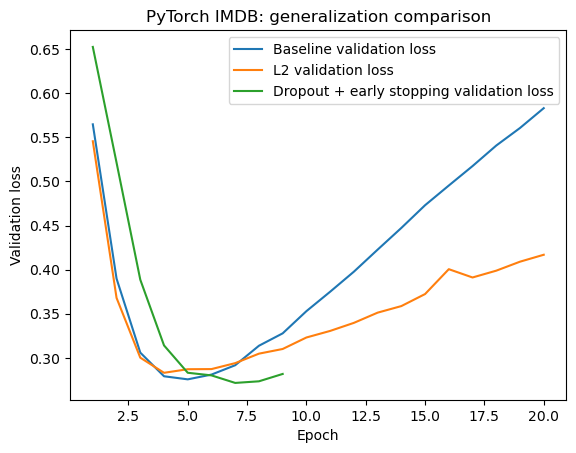

In [56]:
plt.figure()

plt.plot(
    range(1, len(torch_baseline_history["val_loss"]) + 1),
    torch_baseline_history["val_loss"],
    label="Baseline validation loss",
)

plt.plot(
    range(1, len(torch_l2_history["val_loss"]) + 1),
    torch_l2_history["val_loss"],
    label="L2 validation loss",
)

plt.plot(
    range(1, len(torch_regularized_history["val_loss"]) + 1),
    torch_regularized_history["val_loss"],
    label="Dropout + early stopping validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("PyTorch IMDB: generalization comparison")
plt.legend()
plt.show()

### 테스트 데이터에서 최종 평가

In [57]:
torch_baseline_test_loss, torch_baseline_test_acc = evaluate_binary(
    torch_baseline,
    test_loader,
    loss_fn,
    device,
)

torch_l2_test_loss, torch_l2_test_acc = evaluate_binary(
    torch_l2,
    test_loader,
    loss_fn,
    device,
)

torch_regularized_test_loss, torch_regularized_test_acc = evaluate_binary(
    torch_regularized,
    test_loader,
    loss_fn,
    device,
)

print("baseline test loss:", torch_baseline_test_loss)
print("baseline test accuracy:", torch_baseline_test_acc)
print()
print("L2 test loss:", torch_l2_test_loss)
print("L2 test accuracy:", torch_l2_test_acc)
print()
print("dropout + early stopping test loss:", torch_regularized_test_loss)
print("dropout + early stopping test accuracy:", torch_regularized_test_acc)

baseline test loss: 0.6374984250831603
baseline test accuracy: 0.85716

L2 test loss: 0.441892109336853
L2 test accuracy: 0.8568

dropout + early stopping test loss: 0.28422993995189666
dropout + early stopping test accuracy: 0.88576


Keras와 PyTorch에서 수행한 핵심 과정은 같다.

| 과정 | Keras | PyTorch |
|---|---|---|
| L2 가중치 규제 | `kernel_regularizer=regularizers.l2(...)` | optimizer의 `weight_decay` |
| 드롭아웃 | `layers.Dropout()` | `nn.Dropout()` |
| 검증 | `validation_data` | 별도의 검증 루프 |
| 조기 종료 | `EarlyStopping` callback | 검증 손실을 직접 비교하여 구현 |
| 최적 파라미터 복원 | `restore_best_weights=True` | `state_dict()`를 저장하고 다시 불러옴 |
| 훈련 기록 | `History` 객체 | 리스트 또는 딕셔너리에 직접 저장 |

> **두 프레임워크가 구현하는 일반화의 원리는 같지만, PyTorch에서는 훈련과 검증 과정을 코드에서 더 명시적으로 관리한다.**

테스트 정확도만 비교하지 말고 **검증 손실 곡선의 형태**도 함께 확인한다.

생각해볼 점:

- L2 가중치 규제를 적용했을 때 과대적합이 시작되는 시점이나 정도가 달라졌는가?
- 드롭아웃을 적용했을 때 검증 손실의 증가가 완만해졌는가?
- L2와 드롭아웃은 같은 방식으로 모델의 복잡도를 제한하는가?
- 조기 종료는 몇 번째 에포크에서 훈련을 멈추었는가?
- 규제가 항상 테스트 정확도를 높이는가?

## PyTorch에서는 어떻게 연결될까?

P1에서 PyTorch의 훈련 루프를 직접 구현했다.

P2에서 중요한 것은 훈련 루프 자체를 다시 작성하는 것이 아니라
**문제 유형에 따라 출력층과 손실함수가 어떻게 연결되는지** 이해하는 것이다.

Keras와 PyTorch에서는 다음과 같이 대응한다.

| 문제 | Keras 출력층 | Keras loss | PyTorch 출력층 | PyTorch loss |
|---|---|---|---|---|
| 이진 분류 | `Dense(1, sigmoid)` | `binary_crossentropy` | `Linear(..., 1)` | `BCEWithLogitsLoss()` |
| 다중 클래스 분류 | `Dense(K, softmax)` | `sparse_categorical_crossentropy` | `Linear(..., K)` | `CrossEntropyLoss()` |
| 회귀 | `Dense(1)` | `mse` | `Linear(..., 1)` | `MSELoss()` |

PyTorch의 `BCEWithLogitsLoss()`와 `CrossEntropyLoss()`는
각각 sigmoid 또는 softmax에 해당하는 계산을 손실 계산과 결합하여 처리하므로
모델의 마지막 층에 해당 활성화 함수를 별도로 넣지 않는 것이 일반적이다.

In [58]:
import torch
from torch import nn

# 이진 분류
binary_torch_output = nn.Linear(16, 1)
binary_torch_loss = nn.BCEWithLogitsLoss()

# 다중 클래스 분류
multiclass_torch_output = nn.Linear(64, 46)
multiclass_torch_loss = nn.CrossEntropyLoss()

# 회귀
regression_torch_output = nn.Linear(64, 1)
regression_torch_loss = nn.MSELoss()

print(binary_torch_output)
print(multiclass_torch_output)
print(regression_torch_output)

Linear(in_features=16, out_features=1, bias=True)
Linear(in_features=64, out_features=46, bias=True)
Linear(in_features=64, out_features=1, bias=True)


## 세 문제 비교

이번 실습에서 가장 중요한 차이는 **신경망의 앞부분보다 출력층과 손실함수**에 있다.

| 문제 | 최종 출력의 의미 | 출력층 | 손실함수 |
|---|---|---|---|
| IMDB | 긍정일 가능성 | 1 + sigmoid | binary crossentropy |
| Reuters | 46개 주제의 확률 | 46 + softmax | sparse categorical crossentropy |
| California Housing | 주택가격 | 1 + 활성화 없음 | MSE |

> **문제의 타깃이 무엇인지 먼저 파악한 뒤 출력층, 손실함수, 평가지표를 결정한다.**

## 실습 정리

이번 실습의 전체 흐름은 다음과 같다.

> **문제 유형 확인 → 데이터 준비 → 출력층과 손실함수 선택 → 훈련 → 검증 → 테스트 평가 → 일반화 개선**

다음을 기억한다.

- 이진 분류에서는 하나의 sigmoid 출력을 사용할 수 있다.
- 다중 클래스 분류에서는 클래스 수만큼의 softmax 출력을 사용할 수 있다.
- 회귀에서는 출력값의 범위를 제한하지 않는 출력층을 사용할 수 있다.
- 검증 데이터는 모델 선택과 훈련 과정 판단에 사용하고, 테스트셋은 최종 평가에 사용한다.
- 교차 검증은 분류와 회귀 모두에 적용할 수 있으며, 이번 실습에서는 California Housing에 3겹 교차 검증을 적용하여 RMSE의 평균으로 일반화 성능을 평가한다.
- 훈련 성능이 계속 좋아져도 검증 성능은 나빠질 수 있다.
- 드롭아웃과 조기 종료는 과대적합을 완화하고 일반화 성능을 개선하는 데 사용할 수 있다.
- `ModelCheckpoint`를 이용하면 검증 성능이 가장 좋았던 모델을 저장할 수 있다.
- `ReduceLROnPlateau`를 이용하면 검증 성능이 정체될 때 학습률을 줄일 수 있다.
- PyTorch에서는 문제 유형에 맞는 손실함수를 선택하되, 일부 활성화 계산이 손실함수에 포함된다.
- 과대적합을 완화하기 위해 L2 가중치 규제, 드롭아웃, 조기 종료를 적용하고 검증 손실의 변화를 비교한다.

## 확인 과제

1. IMDB 모델의 출력층을 `Dense(2, activation="softmax")`로 바꾸려면 타깃과 손실함수를 어떻게 바꾸어야 하는지 설명하라.
2. Reuters에서 `accuracy`와 `top-3 accuracy`가 서로 다른 정보를 제공하는 이유를 설명하라.
3. California Housing 회귀 모델의 마지막 층에 sigmoid를 사용하면 어떤 문제가 생길 수 있는지 설명하라.
4. IMDB 기본 모델과 규제 모델의 검증 손실 곡선을 비교하고, 과대적합이 시작되는 시점을 설명하라.
5. 테스트셋을 여러 모델을 선택하는 과정에서 반복해서 사용하면 안 되는 이유를 설명하라.
6. 교차 검증이 분류와 회귀 모두에 적용될 수 있는 이유를 설명하고, California Housing에서 세 fold의 RMSE를 평균하는 이유를 설명하라.
7. L2 가중치 규제가 과대적합을 완화하는 원리를 설명하고, 드롭아웃과의 차이를 설명하라.